In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Fitted parameter p: 0.9598


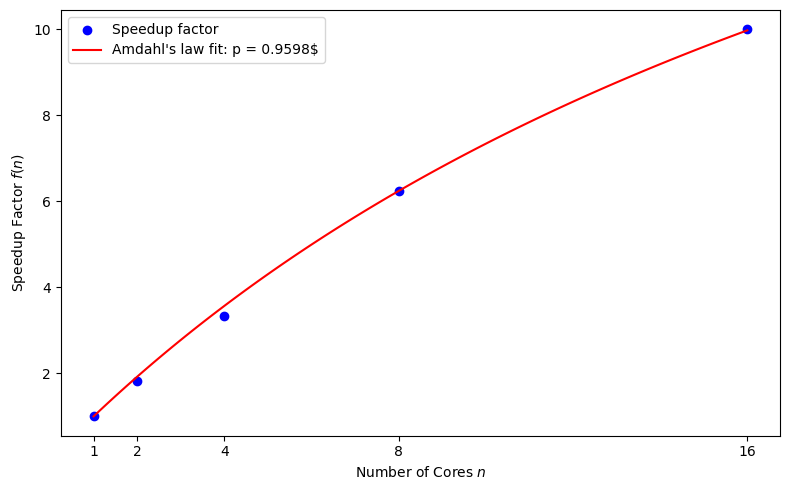

In [6]:
cores = np.array([1, 2, 4, 8, 16])    
times = np.array([100.0, 55.0, 30.0, 16.0, 10.0]) 

speedup = times[0] / times  

def amdahls_law(n, p):
    return 1 / (1 - p + p / n)

popt, pcov = curve_fit(amdahls_law, cores, speedup, p0=[0.5], bounds=(0, 1))
p_fit = popt[0]

print(f"Fitted parameter p: {p_fit:.4f}")

plt.figure(figsize=(8, 5))

plt.scatter(cores, speedup, color='blue', label='Speedup factor')

cores_smooth = np.linspace(min(cores), max(cores), 100)
speedup_fit = amdahls_law(cores_smooth, p_fit)
plt.plot(cores_smooth, speedup_fit, color='red', linestyle='-', 
         label=f"Amdahl's law fit: p = {p_fit:.4f}$")

plt.xlabel("Number of Cores $n$")
plt.ylabel("Speedup Factor $f(n)$")
plt.xticks(cores) 
#plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()
